# 2D Plotting results
Plotting the results from Sparse and L2 inversions in a grid

In [2]:
# SimPEG functionality
import simpeg.electromagnetics.frequency_domain as fdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TensorMesh

# Common Python functionality
import os
import numpy as np
import pandas as pd
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import ipywidgets
import dill
import warnings
%matplotlib inline
mpl.rcParams.update({"font.size": 12})
from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import interp1d


#Import helper functions
import sys
import data_functions, inversion_functions


In [46]:
# Define functions for plotting

import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings

def plot_model(X, Y, model_matrix, min_y=None, log_norm=True, title="2D Resistivity Section with Topography", plot_save=True, save_name="resistivity_section.png"):
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        
        fig, ax = plt.subplots(figsize=(15, 4))

        if log_norm:
            c = ax.pcolormesh(
                X, Y, model_matrix,
                shading='auto',
                cmap='jet_r',
                norm=LogNorm(vmin=1e0, vmax=0.5e4)
            )
        else:
            c = ax.pcolormesh(
                X, Y, model_matrix,
                shading='auto',
                cmap='jet_r'
            )
        
        cb = fig.colorbar(c, ax=ax, label="Resistivity (Ohm·m)")
        
        ax.set_title(title)
        ax.set_xlabel("Distance (m)")
        ax.set_ylabel("Altitude (m)")
        ax.invert_xaxis()
        ax.set_ylim(min_y, Y.max() + 10)

        plt.tight_layout()

        # 🔽 Create outputs folder if it doesn't exist
        os.makedirs("outputs", exist_ok=True)

        # 🔽 Save the figure
        if plot_save:
            save_path = os.path.join("outputs", save_name)
            plt.savefig(save_path, dpi=300)
            print(f"Figure saved to {save_path}")

        plt.show()


#Function to interpolate to greate finer grid of results:
def interpolate_model_matrix(dist, depth_centers, model_matrix,
                              n_depths_fine=300, n_dists_fine=1000):
    """
    Interpolates a 2D resistivity/conductivity model matrix onto a finer regular grid.

    Parameters:
    - dist: 1D array of station distances (length = n_stations)
    - depth_centers: 1D array of depth or elevation centers (length = n_depths)
    - model_matrix: 2D array of shape (n_depths, n_stations)
    - n_depths_fine: number of interpolated depth levels (default: 300)
    - n_dists_fine: number of interpolated station positions (default: 1000)

    Returns:
    - dist_fine, depth_centers_fine: fine grid 1D axes
    - model_fine: interpolated model matrix
    """
    # Create interpolator
    interp_func = RegularGridInterpolator(
        (depth_centers, dist),
        model_matrix,
        bounds_error=False,
        fill_value=np.nan
    )

    # Create fine grids
    depth_centers_fine = np.linspace(depth_centers.min(), depth_centers.max(), n_depths_fine)
    dist_fine = np.linspace(dist.min(), dist.max(), n_dists_fine)

    # Interpolate onto fine grid
    X_fine, Y_fine = np.meshgrid(dist_fine, depth_centers_fine)
    points = np.column_stack((Y_fine.ravel(), X_fine.ravel()))
    model_fine = interp_func(points).reshape(n_depths_fine, n_dists_fine)

    return model_fine, dist_fine, depth_centers_fine


#Functio to remove noisy soundings
def filter_outlier_soundings(model_matrix, dist, threshold=0.1, k=3):
    """
    Filters out columns (soundings) from model_matrix that deviate significantly from the average
    of their k neighbors on either side.

    Parameters:
    - model_matrix: 2D array of shape (n_layers, n_stations)
    - dist: 1D array of shape (n_stations,)
    - threshold: relative deviation threshold (e.g., 0.1)
    - k: number of neighbors on each side to use in averaging

    Returns:
    - model_clean: 2D array with outlier columns removed
    - dist_clean: 1D array with corresponding distances
    """
    M = model_matrix.copy()
    n_layers, n_stations = M.shape
    keep = np.ones(n_stations, dtype=bool)

    for i in range(k, n_stations - k):
        neighbors = np.hstack([
            M[:, i - j].reshape(-1, 1) for j in range(k, 0, -1)
        ] + [
            M[:, i + j].reshape(-1, 1) for j in range(1, k + 1)
        ])

        avg_neighbor = np.mean(neighbors, axis=1)
        center = M[:, i]

        deviation = np.linalg.norm(center - avg_neighbor) / np.linalg.norm(avg_neighbor)

        if deviation > threshold:
            keep[i] = False

    model_clean = M[:, keep]
    dist_clean = np.array(dist)[keep]

    print(f"Removed {np.sum(~keep)} soundings with deviation > {threshold}")
    return model_clean, dist_clean


# Read the halfspace inversion outputus:

Read from csv file for the sparse inversion

In [5]:
# Path to saved data, output folder. same directory
data_filename = os.path.join("outputs", "L530030_sparse_conductivities_singlebeta_2.csv")

#Real the values and the fid_n
df = pd.read_csv(data_filename, sep=",", header=0, dtype={"id": float, "value": float})

# Drop the 'fid' column and convert remaining values to NumPy array
models = df.drop(columns=["fid", "dist", 'dtm']).to_numpy()
models_T = models.T


fids = df["fid"] # index, ids of soundings
dist = df["dist"] #Distances, x locations of soundings
dtm = df["dtm"].T #Altitudes

# Define cells layers and dimensions

In [7]:
conductivities_hsp = 0.02509505880178108
# Set Halfspace conductivity:
resistivities_hsp = 1/conductivities_hsp

resistivities_hsp
depth_min = 1
### Calculate max depth ###
min_frequency = 400
skin_depth = 503*np.sqrt(resistivities_hsp/np.min(min_frequency))
depth_max = 2*skin_depth  # depth to lowest layer

geometric_factor=1.2

# This is from your mesh construction
layer_thicknesses = [depth_min]
while np.sum(layer_thicknesses) < depth_max:
    layer_thicknesses.append(geometric_factor * layer_thicknesses[-1])
    
# Add bottom layer to complete model
h = np.r_[layer_thicknesses, layer_thicknesses[-1]]

# Compute depth edges (top to bottom)
depth_edges = np.r_[0, np.cumsum(h)]

# Compute depth centers (for plotting center-aligned models)
depth_centers = (depth_edges[:-1] + depth_edges[1:]) / 2
depth_centers = -depth_centers #[:-1]

#Set models
model_matrix = 1/models_T

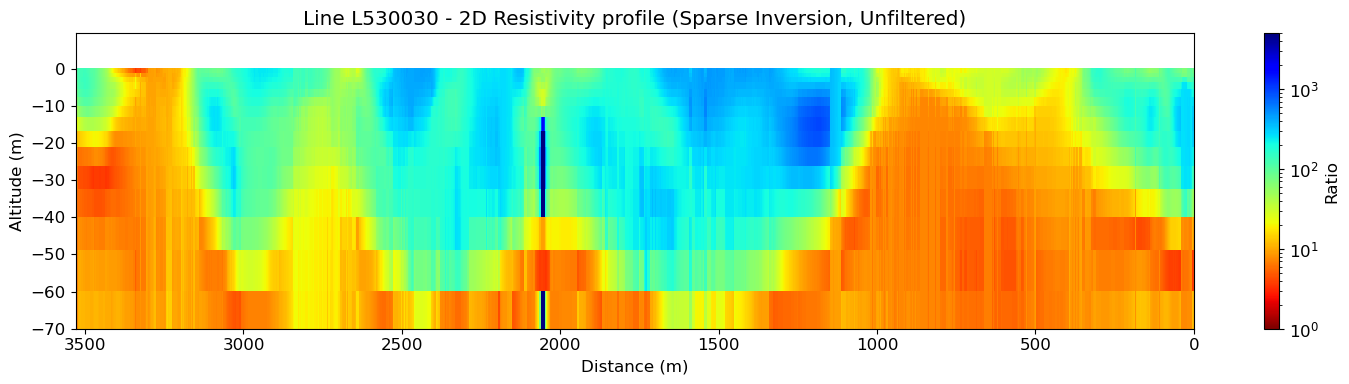

In [8]:
# Create horizontal and vertical grid for pcolormesh
X, Y = np.meshgrid(dist,depth_centers)
#Plot original results
plot_model(X, Y, model_matrix, min_y=-70, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion, Unfiltered)", save_name="sparse_section_org3_L530030.png")

## Adding Altitude from dtm

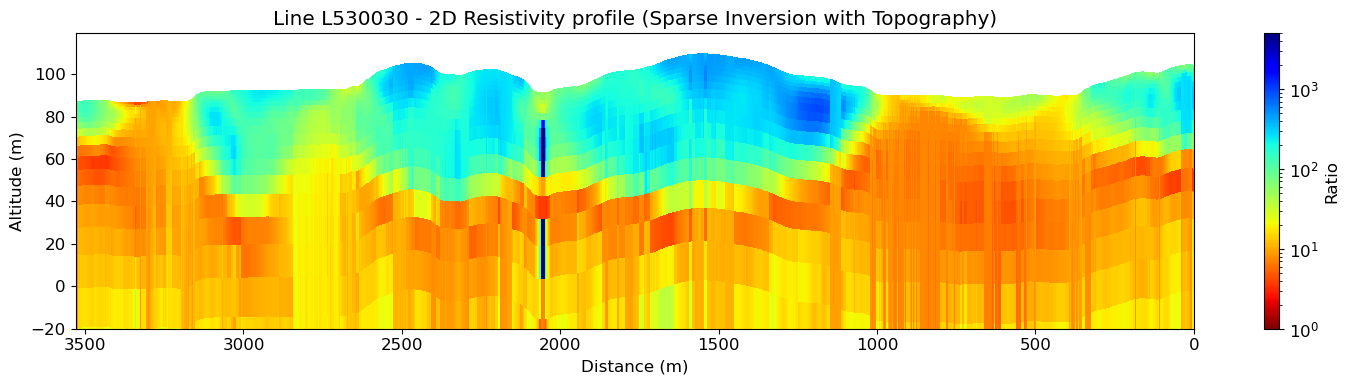

In [10]:
#Create a broadcasted 2D array of dim values (one per column)
surface_elevation_grid = np.tile(dtm, (Y.shape[0], 1))  # shape = (n_depths, n_stations)

#Shift each vertical profile downward from its corresponding surface elevation
Y_shifted = surface_elevation_grid + Y  

#Plot results with altitude
plot_model(X, Y_shifted, model_matrix, min_y=-20, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion with Topography)", save_name="sparse_section_org3_withtopo_L530030.png")

# Interpolation

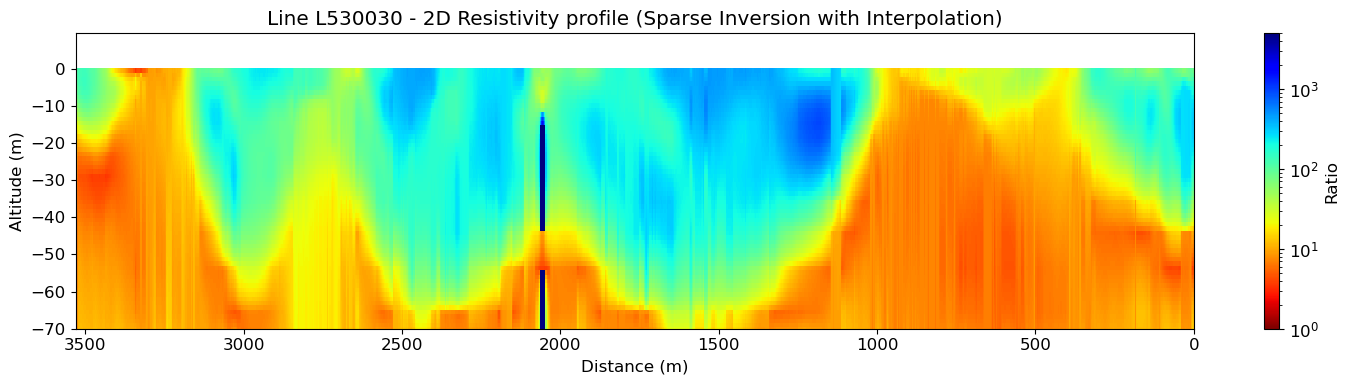

In [12]:
# Interpolate 2D finner grid points
model_fine, dist_fine, depth_centers_fine = interpolate_model_matrix(dist, depth_centers, model_matrix,n_depths_fine=300, n_dists_fine=1000)

# Define fine grid (more rows and columns)
X_fine, Y_fine = np.meshgrid(dist_fine, depth_centers_fine)

plot_model(X_fine, Y_fine, model_fine, min_y=-70, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion with Interpolation)", save_name="sparse_section_org3_inter_L530030.png")

### Adding Altitude to plotting

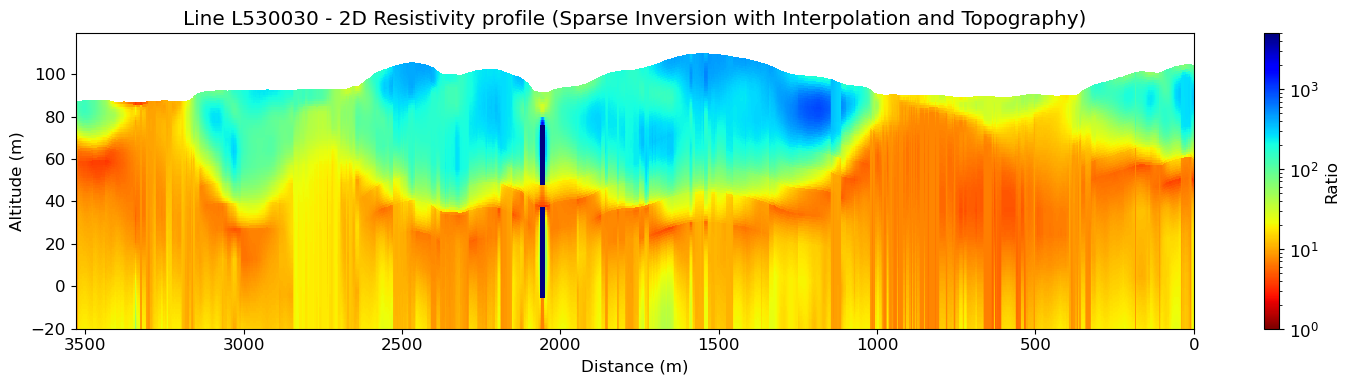

In [14]:
#interpolate for dtm values:
interp_func = interp1d(dist, dtm, kind='linear', bounds_error=False, fill_value='extrapolate')
dtm_fine = interp_func(dist_fine)  # ✅ shape = (1000,)

# Add values
surface_elevation_grid = np.tile(dtm_fine, (Y_fine.shape[0], 1))  # (100, 1000)
Y_shifted = surface_elevation_grid + Y_fine  # this works now

plot_model(X_fine, Y_shifted, model_fine, min_y=-20, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion with Interpolation and Topography)", save_name="sparse_section_org3_inter_topo_L530030.png")

# Remove noisy soundings

Removed 293 soundings with deviation > 0.1


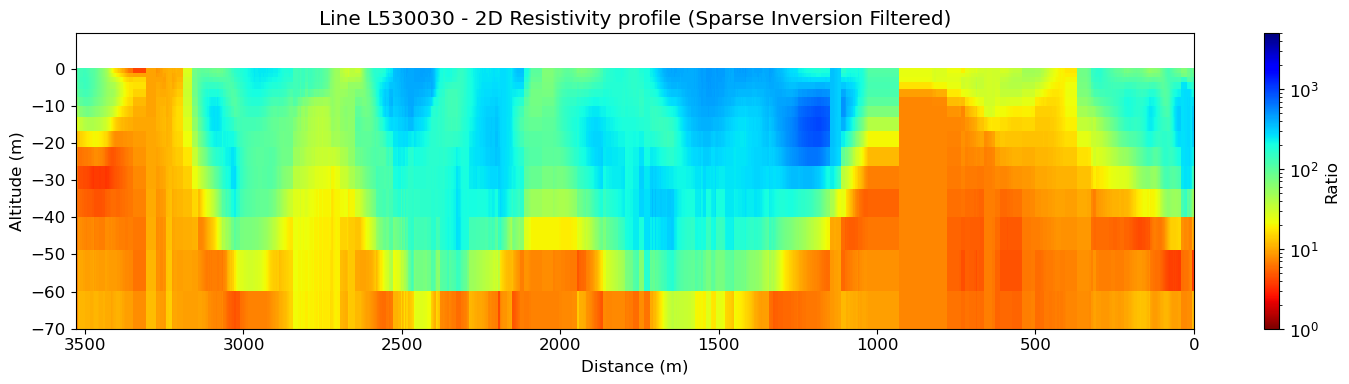

In [16]:
# Remove noisy soundings
model_clean, dist_clean = filter_outlier_soundings(model_matrix, dist, threshold=0.10, k=4)

# Create horizontal and vertical grid 
X_clean, Y_clean = np.meshgrid(dist_clean,depth_centers)

plot_model(X_clean, Y_clean, model_clean, min_y=-70, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion Filtered)", save_name="sparse_section_filer3_L530030.png")

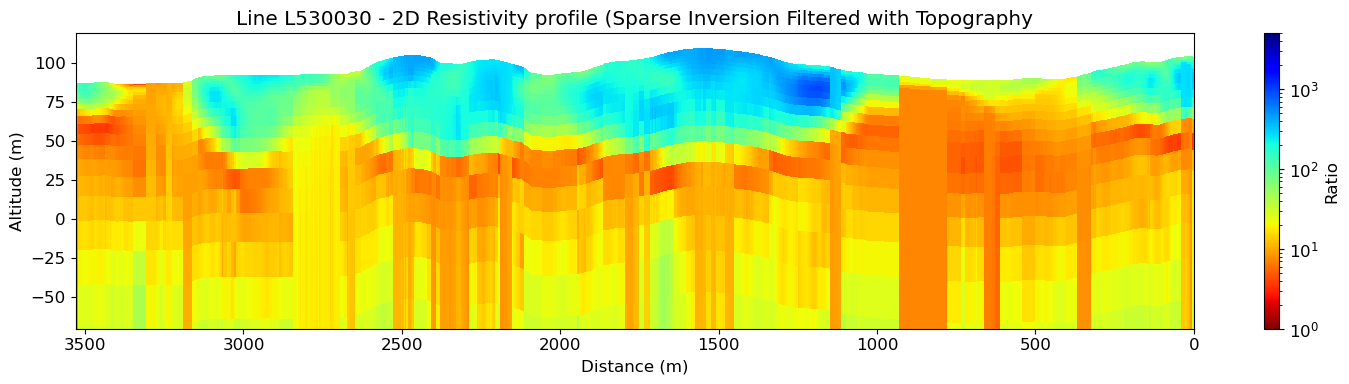

In [17]:
#interpolate for dtm values:
#interp_func = interp1d(dist, dtm, kind='linear', bounds_error=False, fill_value='extrapolate')
dtm_clean = interp_func(dist_clean)  # ✅ shape = (1000,)

# Add values
surface_elevation_grid_clean = np.tile(dtm_clean, (Y_clean.shape[0], 1))  # (100, 1000)
Y_clean_shifted = surface_elevation_grid_clean + Y_clean  # this works now


plot_model(X_clean, Y_clean_shifted, model_clean, min_y=-70, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion Filtered with Topography", save_name="sparse_section_filer3_topo_L530030.png")

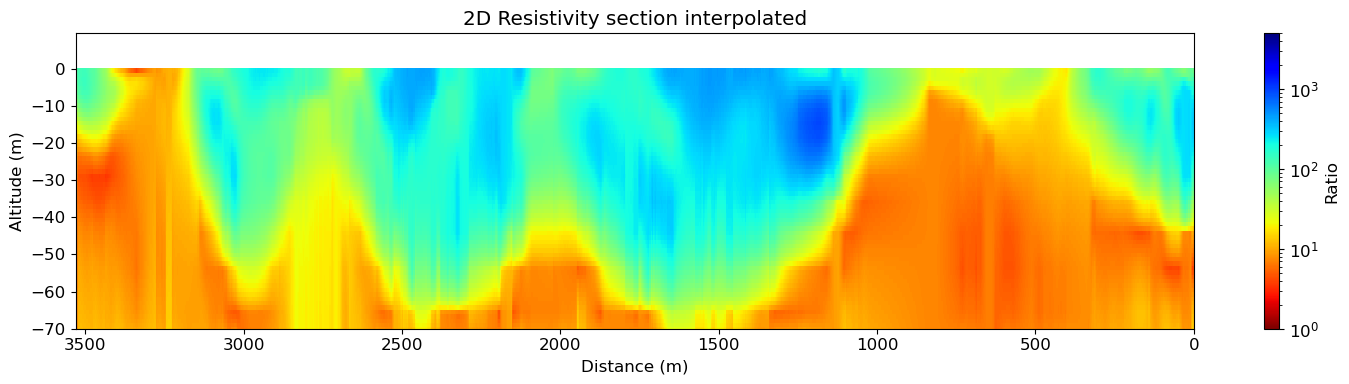

In [18]:
# Add interpolation for denoise model, Interpolate 2D finner grid points
model_clean_fine, dist_clean_fine, depth_centers_fine = interpolate_model_matrix(dist_clean, depth_centers, model_clean, n_depths_fine=300, n_dists_fine=1000)

# Define fine grid (more rows and columns)
X_clean_fine, Y_clean_fine = np.meshgrid(dist_clean_fine, depth_centers_fine)

plot_model(X_clean_fine, Y_clean_fine, model_clean_fine, min_y=-70, log_norm=True, plot_save=False, title="2D Resistivity section interpolated")

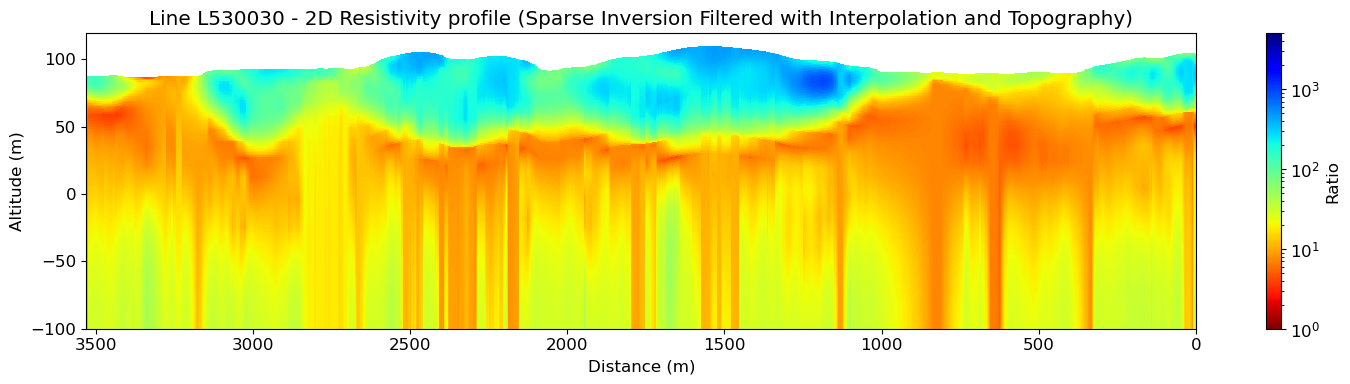

In [19]:
# add the altitude to interpolated results: 

#interpolate for dtm values:
#interp_func = interp1d(dist, dtm, kind='linear', bounds_error=False, fill_value='extrapolate')
dtm_clean_fine = interp_func(dist_clean_fine)  # ✅ shape = (1000,)

# Add values
surface_elevation_grid_clean = np.tile(dtm_clean_fine, (Y_clean_fine.shape[0], 1))  # (100, 1000)
Y_clean_shifted = surface_elevation_grid_clean + Y_clean_fine  # this works now

plot_model(X_clean_fine, Y_clean_shifted, model_clean_fine, min_y=-100, log_norm=True, plot_save=False, title="Line L530030 - 2D Resistivity profile (Sparse Inversion Filtered with Interpolation and Topography)", save_name="sparse_section_filer3_inter_topo_L530030.png")

# Compare results

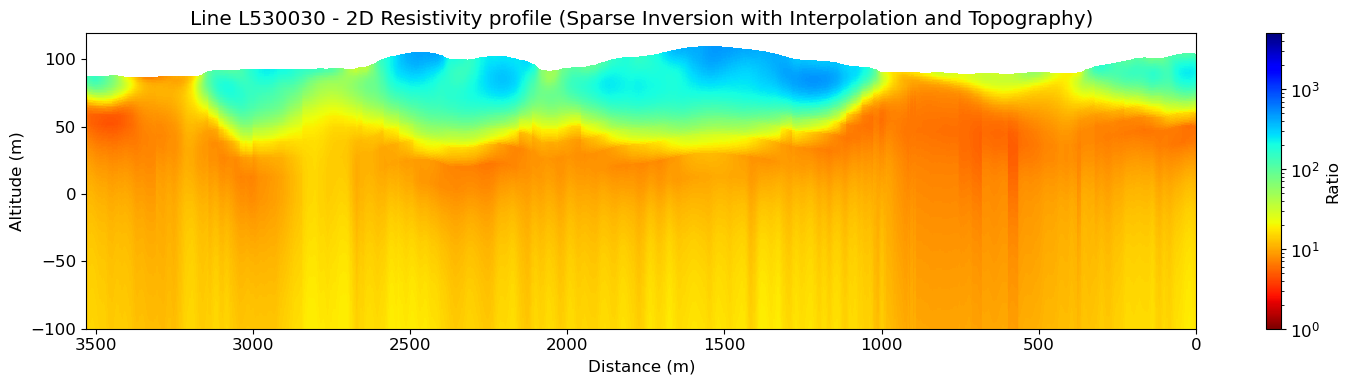

In [21]:
# Path to saved data, output folder. same directory
data_filename = os.path.join("outputs", "L530030_l2_conductivities_singlebeta_1.csv")

#Real the values and the fid_n
df_l2 = pd.read_csv(data_filename, sep=",", header=0, dtype={"id": float, "value": float})

# Drop the 'fid' column and convert remaining values to NumPy array
models_l2 = df_l2.drop(columns=["fid", "dist", 'dtm']).to_numpy()
models_l2_T = models_l2.T

model_matrix_l2 = 1/models_l2_T


fids_l2 = df["fid"] # index, ids of soundings
dist_l2 = df["dist"] #Distances, x locations of soundings
dtm_l2 = df["dtm"].T #Altitudes

# Interpolate 2D finner grid points
model_l2_fine, dist_l2_fine, depth_l2_centers_fine = interpolate_model_matrix(dist_l2, depth_centers, model_matrix_l2, n_depths_fine=300, n_dists_fine=1000)

plot_model(X_fine, Y_shifted, model_l2_fine, min_y=-100, log_norm=True,plot_save=False,  title="Line L530030 - 2D Resistivity profile (Sparse Inversion with Interpolation and Topography)", save_name="sparse_section_org3_inter_topo_L530030.png")




Figure saved to outputs/difference_beta_inversions_L530030.png


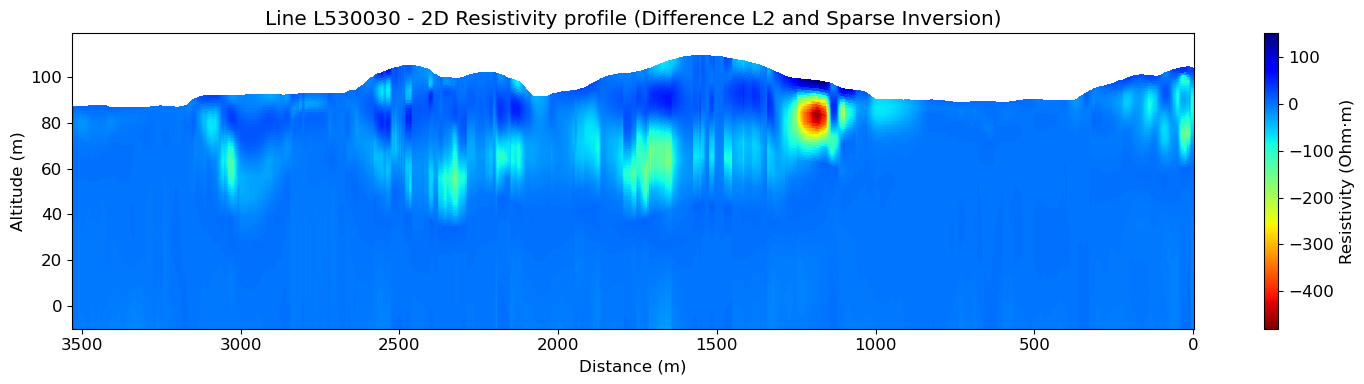

In [50]:
# COmparison:
difference = model_l2_fine - model_clean_fine
#difference = np.abs(model_l2_fine - model_clean_fine)
#difference = (model_clean_fine - model_l2_fine) / model_l2_fine
plot_model(X_fine, Y_shifted, difference, min_y=-10, log_norm=False ,plot_save=True,  title="Line L530030 - 2D Resistivity profile (Difference L2 and Sparse Inversion)", save_name="difference_beta_inversions_L530030.png")


In [52]:
# Example: keep only layers from surface to -10 m
mask_top = Y_fine >= -10  # Or `Y_fine <= 10` if you're using depth below surface

# Optional: use logical AND if you want a range
# mask_top = (Y_fine >= -20) & (Y_fine <= -10)

# Apply the mask to the difference and L2 model
diff_top = (model_clean_fine - model_l2_fine)[mask_top]
l2_top = model_l2_fine[mask_top]

# Compute RMS on those values only
rms_diff = np.sqrt(np.mean(diff_top**2))
rms_l2 = np.sqrt(np.mean(l2_top**2))
relative_rms_diff = rms_diff / rms_l2

print(f"Top-layer RMS difference: {rms_diff:.2f} Ohm·m")
print(f"Top-layer Relative RMS change: {100 * relative_rms_diff:.1f}%")


Top-layer RMS difference: 32.92 Ohm·m
Top-layer Relative RMS change: 15.7%


In [24]:
#> /dev/null

# ToDos
* Use paralelizations and GPUs